# Single-expiry SSVI exploration

This notebook examines the filtered 2025-11-28 smile in total-variance space and shows how the SSVI slice parameters $\rho$, $\theta$, and $\varphi$ change its shape.

In [6]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import least_squares

PANEL_PATH = Path("../data/processed/spx_iv_panel_2025-08-29.csv")
EXPIRY = pd.Timestamp("2025-11-28")

panel = pd.read_csv(
    PANEL_PATH,
    parse_dates=["quote_date", "expiry_date"],
)

MAX_RELATIVE_SPREAD = 0.50
finite_quotes = np.isfinite(
    panel[["best_bid", "best_ask", "mid_price", "mid_iv", "relative_spread"]]
).all(axis=1)
panel["use_for_fit"] = (
    panel["use_for_surface"]
    & finite_quotes
    & panel["best_bid"].gt(0)
    & panel["best_ask"].gt(panel["best_bid"])
    & panel["mid_price"].gt(0)
    & panel["relative_spread"].between(0, MAX_RELATIVE_SPREAD, inclusive="right")
)
fit_rows = panel.loc[
    panel["use_for_fit"] & panel["expiry_date"].eq(EXPIRY)
].copy()
fit_rows["total_variance"] = (
    fit_rows["mid_iv"] ** 2 * fit_rows["time_to_expiry"]
)
fit_rows = fit_rows.sort_values("log_moneyness")

tau = fit_rows["time_to_expiry"].iloc[0]
atm_row = fit_rows.iloc[fit_rows["log_moneyness"].abs().argmin()]
observed_theta = atm_row["mid_iv"] ** 2 * tau

display(
    pd.Series(
        {
            "expiry": EXPIRY.date(),
            "time_to_expiry": tau,
            "filtered_observations": len(fit_rows),
            "nearest_ATM_log_moneyness": atm_row["log_moneyness"],
            "nearest_ATM_iv": atm_row["mid_iv"],
            "observed_theta": observed_theta,
        }
    )
)

expiry                       2025-11-28
time_to_expiry                 0.249315
filtered_observations               414
nearest_ATM_log_moneyness     -0.000113
nearest_ATM_iv                 0.132596
observed_theta                 0.004383
dtype: object

## Observed total variance

For fixed time to expiry $\tau$, convert implied volatility to total variance using

$$
w(k)=\sigma_{\mathrm{IV}}(k)^2\tau,
\qquad
k=\log(K/F).
$$

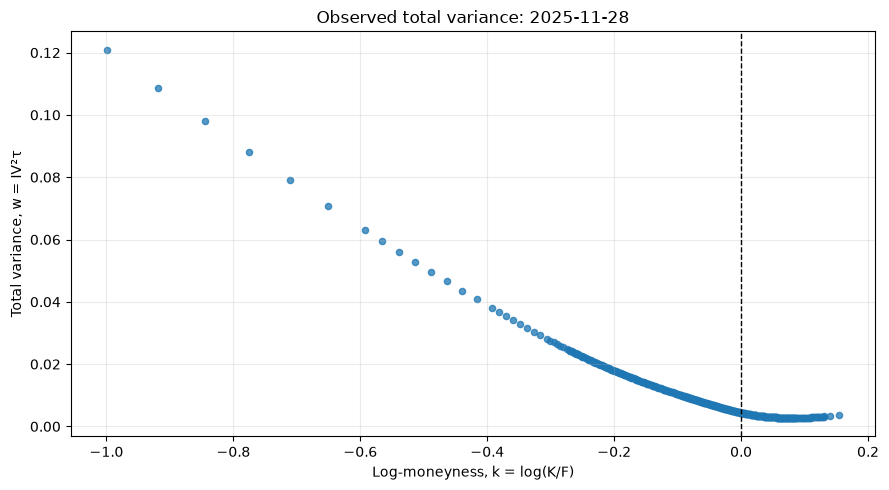

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(
    fit_rows["log_moneyness"],
    fit_rows["total_variance"],
    s=20,
    alpha=0.75,
)
ax.axvline(0, color="black", linestyle="--", linewidth=1)
ax.set(
    title=f"Observed total variance: {EXPIRY.date()}",
    xlabel="Log-moneyness, k = log(K/F)",
    ylabel="Total variance, w = IV²τ",
)
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

## Fit an SSVI slice

We use the SSVI-style single-slice parameterisation

$$
w(k)=\frac{\theta}{2}
\left(
1+\rho\varphi k
+\sqrt{(\varphi k+\rho)^2+1-\rho^2}
\right).
$$

The fitted parameters provide useful defaults for the manual controls below.

rho      -0.501226
theta     0.001591
phi      82.590391
RMSE      0.002553
dtype: float64

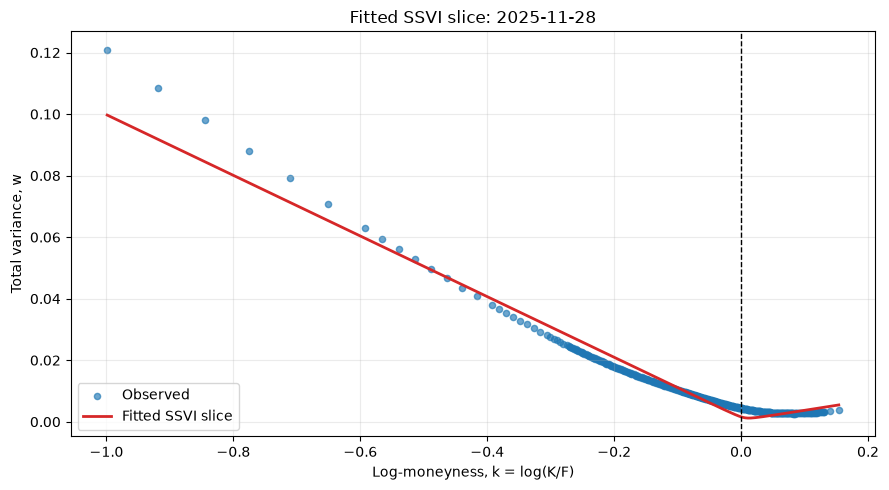

In [8]:
def ssvi_total_variance(k, rho, theta, phi):
    return 0.5 * theta * (
        1
        + rho * phi * k
        + np.sqrt((phi * k + rho) ** 2 + 1 - rho**2)
    )


k_observed = fit_rows["log_moneyness"].to_numpy()
w_observed = fit_rows["total_variance"].to_numpy()

fit = least_squares(
    lambda parameters: (
        ssvi_total_variance(k_observed, *parameters) - w_observed
    ),
    x0=np.array([-0.5, observed_theta, 20.0]),
    bounds=(np.array([-0.999, 1e-8, 1e-8]), np.array([0.999, 5.0, 100.0])),
)
rho, theta, phi = fit.x
fit_rmse = np.sqrt(np.mean(fit.fun**2))
k_grid = np.linspace(k_observed.min(), k_observed.max(), 500)

display(
    pd.Series(
        {"rho": rho, "theta": theta, "phi": phi, "RMSE": fit_rmse}
    )
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(k_observed, w_observed, s=20, alpha=0.65, label="Observed")
ax.plot(
    k_grid,
    ssvi_total_variance(k_grid, rho, theta, phi),
    color="tab:red",
    linewidth=2,
    label="Fitted SSVI slice",
)
ax.axvline(0, color="black", linestyle="--", linewidth=1)
ax.set(
    title=f"Fitted SSVI slice: {EXPIRY.date()}",
    xlabel="Log-moneyness, k = log(K/F)",
    ylabel="Total variance, w",
)
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

## Parameter effects

Holding the other fitted values fixed:

- $\rho$ controls skew direction and strength.
- $\theta$ controls the overall variance level.
- $\varphi$ controls curvature and wing steepness.

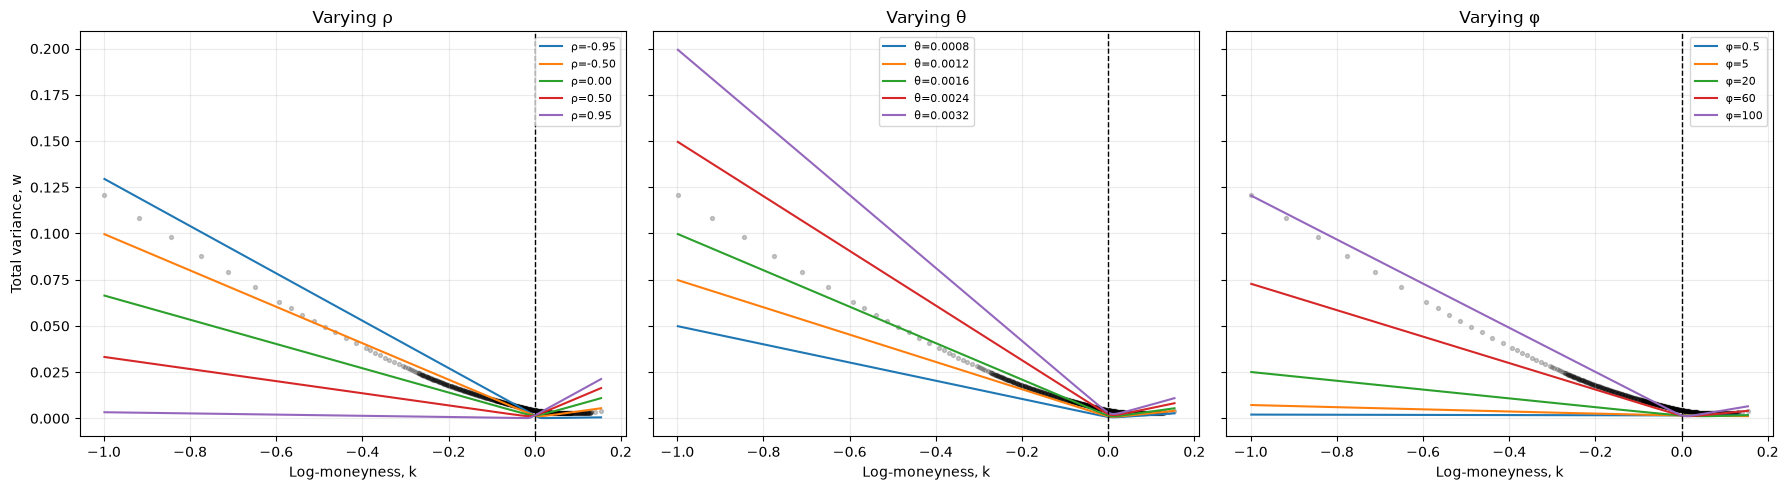

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for value in [-0.95, -0.5, 0.0, 0.5, 0.95]:
    axes[0].plot(k_grid, ssvi_total_variance(k_grid, value, theta, phi), label=f"ρ={value:.2f}")
axes[0].set_title("Varying ρ")

for multiplier in [0.5, 0.75, 1.0, 1.5, 2.0]:
    value = multiplier * theta
    axes[1].plot(k_grid, ssvi_total_variance(k_grid, rho, value, phi), label=f"θ={value:.4f}")
axes[1].set_title("Varying θ")

for value in [0.5, 5.0, 20.0, 60.0, 100.0]:
    axes[2].plot(k_grid, ssvi_total_variance(k_grid, rho, theta, value), label=f"φ={value:g}")
axes[2].set_title("Varying φ")

for ax in axes:
    ax.scatter(k_observed, w_observed, s=8, alpha=0.2, color="black")
    ax.axvline(0, color="black", linestyle="--", linewidth=1)
    ax.set_xlabel("Log-moneyness, k")
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)
axes[0].set_ylabel("Total variance, w")
fig.tight_layout()
plt.show()

## Manual parameter controls

The controls start at the fitted values. Each adjustment replaces the plot in the dedicated output area below rather than appending another figure.

In [ ]:
from IPython.display import display
from ipywidgets import FloatSlider, HBox, interactive_output

rho_slider = FloatSlider(
    value=float(rho), min=-0.95, max=0.95, step=0.01, description="rho"
)
theta_slider = FloatSlider(
    value=float(theta), min=0.0002, max=0.01, step=0.0001,
    readout_format=".4f", description="theta"
)
phi_slider = FloatSlider(
    value=float(phi), min=0.5, max=120.0, step=0.5, description="phi"
)


def plot_ssvi_slice(rho, theta, phi):
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.scatter(k_observed, w_observed, s=20, alpha=0.65, label="Observed")
    ax.plot(
        k_grid,
        ssvi_total_variance(k_grid, rho, theta, phi),
        color="tab:red",
        linewidth=2,
        label="Manual SSVI slice",
    )
    ax.axvline(0, color="black", linestyle="--", linewidth=1)
    ax.set(
        title=f"ρ={rho:.3f}, θ={theta:.4f}, φ={phi:.1f}",
        xlabel="Log-moneyness, k = log(K/F)",
        ylabel="Total variance, w",
    )
    ax.legend()
    ax.grid(alpha=0.25)
    fig.tight_layout()
    plt.show()
    plt.close(fig)


controls = HBox([rho_slider, theta_slider, phi_slider])
plot_output = interactive_output(
    plot_ssvi_slice,
    {"rho": rho_slider, "theta": theta_slider, "phi": phi_slider},
)
display(controls, plot_output)

Output()